# Exercise 1: Generating random numbers in a range

Using numpy.random (or whatever you like), generate:

*	An integer random number in a range [0,5] (using random.integers)
*	100 float random numbers in a range [0,5] (using random.uniform)
*	A 3x3 matrix of floats random number in a range [0,2]

Try using seed and without seed to see the difference.

In [ ]:
import numpy as np

def random_integer(start, end, seed = None):
    np.random.seed(seed)
    return np.random.random_integers(start, end)

def random_floats(start,end, seed = None):
    np.random.seed(seed)
    return np.random.uniform(start,end, 100)

def random_matrix(start, end, rows, columns, seed = None):
    np.random.seed(seed)
    return np.random.uniform(start, end, (rows, columns))

print(random_integer(0,5))
print(random_floats(0,5))
print(random_matrix(0,2,3,3))


Results without seed:
0
[1.19036216 0.21222121 1.42729757 3.55452851 1.91975128 1.51244323
 1.21637758 0.72055755 2.33793313 0.58436052 0.40773138 1.49620539
 0.01470971 0.20307931 4.38466611 3.63103116 3.34718236 2.41341964
 2.64695179 4.63912682 4.32346835 4.96499034 2.55680814 4.79493126
 2.156738   0.24174222 4.41730918 2.54132385 2.57850961 1.78660974
 2.29143297 1.51146106 3.87554242 0.01112386 4.55093308 0.32803099
 3.39377228 2.39506032 2.34484665 1.33047029 3.1369224  4.27420394
 1.58984489 4.60814143 3.19733348 4.2432307  3.25868104 1.88116254
 1.61170758 1.75711223 2.89588405 1.03757554 3.22471741 4.74067772
 2.89526322 4.10468279 1.75786877 1.93833789 3.02037378 0.93138234
 4.41262362 3.49695786 1.92722469 3.41518846 4.29161118 2.25164516
 4.79597276 0.51032249 3.77531452 2.81264542 4.08769167 1.79319316
 2.46026498 4.80273022 0.78992281 3.68816659 2.23396133 4.94640909
 0.96296617 0.85134334 2.80280122 1.07193297 0.40830525 1.09158149
 3.94128459 4.92100497 0.96176725 4.06

C:\Users\Szymon\AppData\Local\Temp\ipykernel_22992\2548879746.py:5: DeprecationWarning: This function is deprecated. Please call randint(0, 5 + 1) instead
  return np.random.random_integers(start, end)


# Exercise 2: Estimating $\pi$ value using the Monte Carlo method

$pi = 4*\dfrac{S_{\text{quarter circle}}}{S_{\text{square}}} \approx 4*\dfrac{\text{points in circle}}{\text{total points in square}}$

Step:
+	Generate a point (x,y) using 2 random numbers in a range [0,1]
+	Check if the point is inside the circle using the condition $x^2+y^2 <= 1 $
+	Repeat this procedure for many points and compute the ratio.
+	Verify the result by comparing |result - $\pi$|


In [6]:
from numpy import pi

def calculate_pi(points_number):

    coordinates = np.random.uniform(0,1, (points_number,2))
    inside_circle = 0

    for i in range(coordinates.shape[0]):
        if coordinates[i][0] ** 2 + coordinates[i][1] ** 2 <= 1:
            inside_circle += 1

    estimated_pi = 4 * inside_circle / coordinates.shape[0]

    error = abs(estimated_pi - pi)

    print(f"Based on {points_number} generated points, the estimated value of pi is {estimated_pi:}, which gives an error of {error:.6f} compared to the true value of pi.")

calculate_pi(100)   

Based on 100 generated points, the estimated value of pi is 3.12, which gives an error of 0.021593 compared to the true value of pi.


# Exercise 3: Monte Carlo Integration

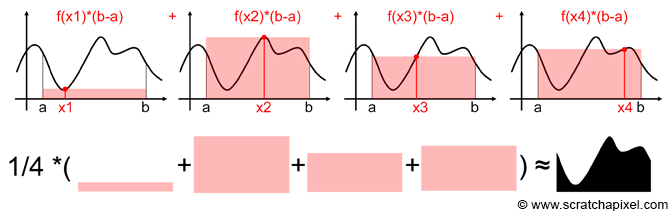

Integration:
$$I = \int_{a}^{b} y(x) dx$$
Monte Carlo Uniform distribution to estimate the integral:
$$\bar{I} = \dfrac{1}{N} \sum_{i=0}^{N-1} I(x_i)= \dfrac{1}{N} \sum_{i=0}^{N-1}(b-a) y(x_i).$$
where $I(x_i) = (b-a)y(x_i)$.

**Standard deviation** of I:
$$ \sigma_{I} =  \sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2}$$
**Standard error** of the estimate:
$$ \sigma_{\bar{I}} =  \dfrac{\sigma_I}{\sqrt{N}}$$
 <!-- $$ \Rightarrow \sigma_{\bar{I}} =  \dfrac{1}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2} =  \dfrac{(b-a)}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (y(x_i) - \overline{y})^2}$$ -->

+	Define a function named **MC_1dim(lower_bound,upper_bound,func,n_points)** to compute the integral of an arbitrary one-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and  the standard error  $\sigma_{\bar{I}}$ , i.e $<I> = \bar{I} \pm \sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi} sin(x) dx$ 

+	Verify the result by calculating the absolute error: $|\bar{I} - 2|$
+	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases?
+	Compare the convergence of the Monte Carlo method and the trapezoid (use np.trapezoid()) method by plotting the absolute error of both approaches using log-log scale. Which method converges faster for this one-dimensional integral? 
+	How do these method errors scale as O($1/N^{\alpha}$). Compute the slope to find the $\alpha$ value for each method by choosing any 2 pairs $(x_1,y_1), (x_2,y_2)$ from the log-log plot:

	$\alpha = -\dfrac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}$

Hint: The expected values are $\alpha_{MC} = 0.5$ and $\alpha_{trapezoid} = 2$.

# Exercise 4: Higher dimension integration
In n-dimension

Simple Integration:
$$I = \int_{a}^{b}\int_{a}^{b} ...\int_{a}^{b}dx_1dx_2...dx_n f(x_1,x_2,...,x_n)$$
The estimation value:
$$\bar{I} = (b-a)^n \sum_{i=0}^{N-1} \dfrac{f(x_{1i},x_{2i},...,x_{ni})}{N}.$$
**Standard error** of the estimate:
 $$ \sigma_{\bar{I}} =    \dfrac{(b-a)^n}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (f(x_{1i},x_{2i},...,x_{ni}) - \overline{f})^2}$$

+	Define a function named **MC_ndim(lower,upper,func,n_dims,n_points)** to compute the integral of an arbitrary n-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and the standard error $\sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi}\int_{0}^{\pi} sin(x_1) sin(x_2) dx_1 dx_2$ 

+ Compute the above integral for $n_{dims} = 5,7,9$ and plot the absolute values $|\bar{I} - 2^n|$ for these dimension values as a function of n_points using log-log scale. Does the slope of error line change when we increase the dimension ? What is your conclusion ? 